---
## PART 1 : Installing the necessary libraries

In [14]:
# download the UCI datasets
!pip install ucimlrepo -q

---
## STEP 1: Dataset Search

**Dataset Description (Dataset 1):**
- 400 patients, 25 medical attributes
- Binary target: `ckd` (sick) or `notckd` (healthy)

In [49]:
#  DOWNLOAD DATASET 1
from ucimlrepo import fetch_ucirepo

# ID=336 corresponds to the Chronic Kidney Disease dataset on UCI
chronic_kidney_disease = fetch_ucirepo(id=336)

X_raw = chronic_kidney_disease.data.features
y_raw = chronic_kidney_disease.data.targets

print("Dataset successfully downloaded!")
print(f"Dataset size: {X_raw.shape[0]} rows × {X_raw.shape[1]} columns")
print(f"Target classes: {y_raw.iloc[:,0].unique()}")

Dataset successfully downloaded!
Dataset size: 400 rows × 24 columns
Target classes: ['ckd' 'ckd\t' 'notckd']


In [50]:
# Displaying dataset metadata
print(chronic_kidney_disease.metadata)
print("\n Available variables:")
print(chronic_kidney_disease.variables)

{'uci_id': 336, 'name': 'Chronic Kidney Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/336/data.csv', 'abstract': 'This dataset can be used to predict the chronic kidney disease and it can be collected from the hospital nearly 2 months of period.', 'area': 'Other', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 400, 'num_features': 24, 'feature_types': ['Real'], 'demographics': ['Age'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Mar 04 2024', 'dataset_doi': '10.24432/C5G020', 'creators': ['L. Rubini', 'P. Soundarapandian', 'P. Eswaran'], 'intro_paper': None, 'additional_info': {'summary': 'We use the following representation to collect the dataset\r\n                        age\t\t-\tage\t\r\n\t\t\tbp\t\t-\tblood pressure\r\n\t\t\tsg\t

---
## STEP 2: Generative AI Dataset 2

In [51]:
# DATASET 2 GENERATION: Synthetic Data
# We use NumPy to simulate synthetic data
import numpy as np
import pandas as pd

np.random.seed(42)
n_synthetic = 100

# We generate numerical data similar to real medical ranges
dataset2 = pd.DataFrame({
    'age':        np.random.randint(20, 90, n_synthetic),
    'bp':         np.random.choice([70, 80, 90, 100, 110], n_synthetic),  # Blood Pressure
    'sg':         np.random.choice([1.005, 1.010, 1.015, 1.020, 1.025], n_synthetic),  # Specific Gravity
    'al':         np.random.choice([0, 1, 2, 3, 4, 5], n_synthetic),     # Albumin
    'su':         np.random.choice([0, 1, 2, 3, 4, 5], n_synthetic),     # Sugar
    'bgr':        np.random.randint(70, 500, n_synthetic),  # Blood Glucose Random
    'bu':         np.random.uniform(10, 200, n_synthetic).round(1),  # Blood Urea
    'sc':         np.random.uniform(0.4, 15, n_synthetic).round(1),  # Serum Creatinine
    'hemo':       np.random.uniform(3.1, 17.8, n_synthetic).round(1),  # Hemoglobin
    'pcv':        np.random.randint(9, 54, n_synthetic),   # Packed Cell Volume
    'wbcc':       np.random.randint(2200, 26400, n_synthetic),  # WBC Count
    'rbcc':       np.random.uniform(2.1, 8, n_synthetic).round(1),  # RBC Count
})

# Simple medical rule for creating the synthetic label

dataset2['classification'] = np.where(
    (dataset2['sc'] > 5) | (dataset2['hemo'] < 8) | (dataset2['bu'] > 100),
    'ckd', 'notckd'
)

print("Synthetic Dataset 2 generated")
print(f"Size: {dataset2.shape}")
print(f"Class distribution:")
print(dataset2['classification'].value_counts())
dataset2.head()

Synthetic Dataset 2 generated
Size: (100, 13)
Class distribution:
classification
ckd       91
notckd     9
Name: count, dtype: int64


,age,bp,sg,al,su,bgr,bu,sc,hemo,pcv,wbcc,rbcc,classification
0,71,110,1.015,5,4,246,81.5,8.0,14.7,48,11724,3.5,ckd
1,34,80,1.020,1,2,168,25.9,11.7,10.4,48,22091,2.7,ckd
2,80,90,1.020,2,3,105,157.7,8.0,4.4,47,8656,3.5,ckd
3,40,70,1.005,5,1,165,116.1,12.8,11.0,14,6412,6.4,ckd
4,43,80,1.005,1,2,221,90.6,8.5,11.7,14,15424,7.1,ckd


---
## STEP 3 : Dataset Loading and Preparation

In [52]:
# IMPORT OF LIBRARY MAINS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

print("All libraries successfully imported!")

All libraries successfully imported!


In [56]:
# INITIAL EXPLORATION OF DATASET 1
# Creation of the complete DataFrame (features + target)
df = X_raw.copy()

df['classification'] = y_raw.iloc[:, 0].values
print("PREVIEW OF THE FIRST LINES:")
print(df.head())

print("=" * 50)
print("DIMENSIONS OF YOUR DATASET:")
print(f"   {df.shape[0]} patients × {df.shape[1]} columns")

print("=" * 50)
print("DATA TYPES:")
print(df.dtypes)

print("=" * 50)
print("DESCRIPTIVE STATISTICS:")
print(df.describe())

PREVIEW OF THE FIRST LINES:
    age    bp     sg   al   su     rbc        pc         pcc          ba  \
0  48.0  80.0  1.020  1.0  0.0     NaN    normal  notpresent  notpresent   
1   7.0  50.0  1.020  4.0  0.0     NaN    normal  notpresent  notpresent   
2  62.0  80.0  1.010  2.0  3.0  normal    normal  notpresent  notpresent   
3  48.0  70.0  1.005  4.0  0.0  normal  abnormal     present  notpresent   
4  51.0  80.0  1.010  2.0  0.0  normal    normal  notpresent  notpresent   

     bgr  ...   pcv    wbcc  rbcc  htn   dm  cad  appet   pe  ane  \
0  121.0  ...  44.0  7800.0   5.2  yes  yes   no   good   no   no   
1    NaN  ...  38.0  6000.0   NaN   no   no   no   good   no   no   
2  423.0  ...  31.0  7500.0   NaN   no  yes   no   poor   no  yes   
3  117.0  ...  32.0  6700.0   3.9  yes   no   no   poor  yes  yes   
4  106.0  ...  35.0  7300.0   4.6   no   no   no   good   no   no   

  classification  
0            ckd  
1            ckd  
2            ckd  
3            ckd  
4    

ANALYSIS OF MISSING VALUES:
       Missing Values  Percentage (%)
rbc               152           38.00
rbcc              131           32.75
wbcc              106           26.50
pot                88           22.00
sod                87           21.75
pcv                71           17.75
pc                 65           16.25
hemo               52           13.00
su                 49           12.25
sg                 47           11.75
al                 46           11.50
bgr                44           11.00
bu                 19            4.75
sc                 17            4.25
bp                 12            3.00
age                 9            2.25
pcc                 4            1.00
ba                  4            1.00
htn                 2            0.50
dm                  2            0.50
cad                 2            0.50
appet               1            0.25
pe                  1            0.25
ane                 1            0.25


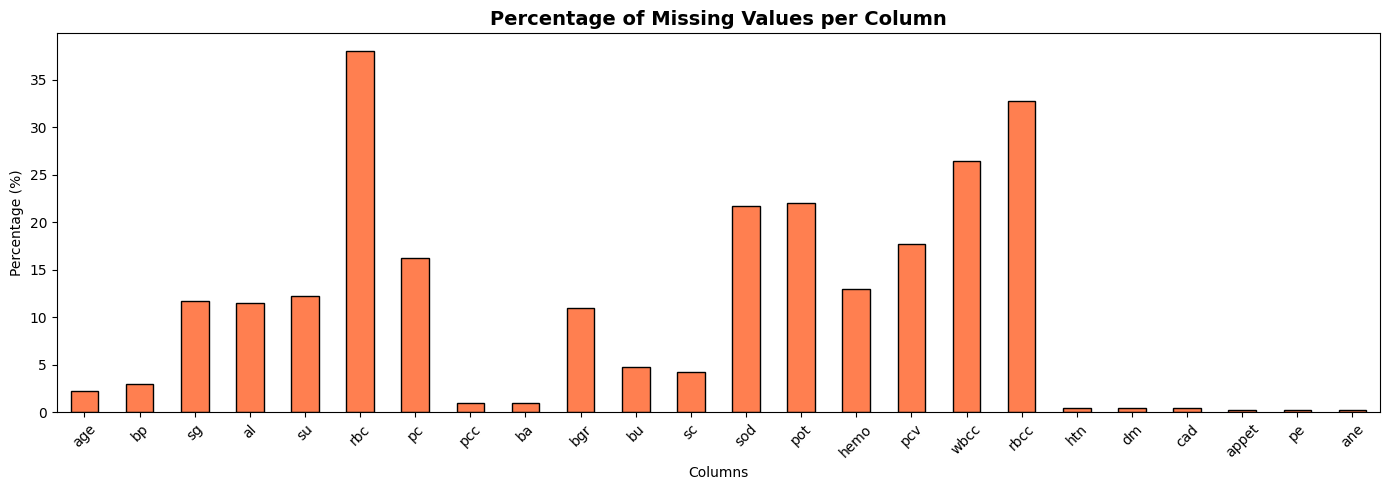

In [60]:
# MISSING VALUES: Analysis

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_pct.round(2)
}).sort_values('Missing Values', ascending=False)
print("ANALYSIS OF MISSING VALUES:")
print("=" * 50)
print(missing_df[missing_df['Missing Values'] > 0])

# Visualisation des valeurs manquantes
plt.figure(figsize=(14, 5))
missing_pct[missing_pct > 0].plot(kind='bar', color='coral', edgecolor='black')
plt.title('Percentage of Missing Values ​​per Column', fontsize=14, fontweight='bold')
plt.xlabel('Columns')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [62]:
# DATA CLEANING
# Step 1: Cleaning up unnecessary spaces in the columns
df_clean = df.copy()

cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns: {cat_cols}")

# Cleaning up spaces in text columns
for col in cat_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()
    # Replacing 'nan' (string) values ​​with real NaN
    df_clean[col] = df_clean[col].replace('nan', np.nan)

print("\n Cleaning of spaces complete")

# --- Step 2: Removing duplicates ---
n_before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
n_after = len(df_clean)
print(f"\nDuplicates removed: {n_before - n_after} rows")
print(f"Size after deletion: {df_clean.shape}")

Categorical columns: ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']

 Cleaning of spaces complete

Duplicates removed: 0 rows
Size after deletion: (400, 25)


In [63]:
# MANAGING MISSING VALUES

# Separate numerical and categorical features*
num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
# Remove the target from the categorical list
if 'classification' in cat_cols:
    cat_cols.remove('classification')

print(f"Numeric columns ({len(num_cols)}): {num_cols}")
print(f"Categorical columnss ({len(cat_cols)}): {cat_cols}")

# Imputation of numerical values ​​using the median
imputer_num = SimpleImputer(strategy='median')
df_clean[num_cols] = imputer_num.fit_transform(df_clean[num_cols])

# Imputation of categorical values ​​by mode
imputer_cat = SimpleImputer(strategy='most_frequent')
df_clean[cat_cols] = imputer_cat.fit_transform(df_clean[cat_cols])

# Verification: no more missing values
total_missing = df_clean.isnull().sum().sum()
print(f"\n Remaining missing values: {total_missing}")

Numeric columns (14): ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']
Categorical columnss (10): ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

 Remaining missing values: 0


In [64]:
# ENCODING OF CATEGORICAL VARIABLES
le = LabelEncoder()

# Encoding of each categorical column
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    print(f"'{col}' encoded")

# Target encoding: ckd=1, notckd=0
df_clean['classification'] = df_clean['classification'].map(
    lambda x: 1 if str(x).strip().lower() == 'ckd' else 0
)

print(f"\n Distribution of classes after encoding:")
print(df_clean['classification'].value_counts())
print(f"   1 = CKD (Malade), 0 = NotCKD (Sain)")

# Final display of the cleaned dataset
print(f"\n Dataset final: {df_clean.shape}")
df_clean.head()

'rbc' encoded
'pc' encoded
'pcc' encoded
'ba' encoded
'htn' encoded
'dm' encoded
'cad' encoded
'appet' encoded
'pe' encoded
'ane' encoded

 Distribution of classes after encoding:
classification
1    250
0    150
Name: count, dtype: int64
   1 = CKD (Malade), 0 = NotCKD (Sain)

 Dataset final: (400, 25)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,0,0,0,1
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,38.0,6000.0,4.8,0,0,0,0,0,0,1
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,31.0,7500.0,4.8,0,1,0,1,0,1,1
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,1,1,1,1
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,0,0,0,0,0,1


In [67]:
# DATA AUGMENTATION Merge Dataset 1 + Dataset 2
# Dataset 1 (actual UCI) = 400 patients
# Dataset 2 (synthetic) = 100 patients
# Combined Dataset = 500 patients

print("=" * 55)
print("DATA AUGMENTATION: Before the merger")
print("=" * 55)
print(f"Dataset 1:   {df_clean.shape[0]} patients")
print(f"Dataset 2 : {len(dataset2)} patients")

# Step 1: Align Dataset 2 with the columns of Dataset 1
dataset2_aligned = pd.DataFrame(
    index=range(len(dataset2)),
    columns=df_clean.columns
)

# Fill all columns with the median of Dataset 1
for col in df_clean.columns:
    if col != 'classification':
        dataset2_aligned[col] = df_clean[col].median()

# Replace the common columns with the actual values ​​from Dataset 2
common_cols = ['age', 'bp', 'sc', 'hemo', 'bu', 'pcv']
for col in common_cols:
    if col in dataset2.columns and col in dataset2_aligned.columns:
        dataset2_aligned[col] = dataset2[col].values

# Encode the target: ckd=1, notckd=0
dataset2_aligned['classification'] = dataset2['classification'].map(
    lambda x: 1 if str(x).strip().lower() == 'ckd' else 0
).values

# Convert everything to float
dataset2_aligned = dataset2_aligned.astype(float)

# Step 2: Melting + Blending
df_augmented = pd.concat(
    [df_clean, dataset2_aligned],
    ignore_index=True,
    axis=0
)
df_augmented = df_augmented.sample(
    frac=1, random_state=42
).reset_index(drop=True)

print("=" * 50)
print("DATA AUGMENTATION: After the merger")
print("=" * 50)
print(f"Combined dataset: {df_augmented.shape[0]} patients × {df_augmented.shape[1]} columns")
print(f" Augmentation: +{df_augmented.shape[0] - df_clean.shape[0]} patients "
      f"(+{(df_augmented.shape[0]/df_clean.shape[0]-1)*100:.0f}%)")

vc = df_augmented['classification'].value_counts()
print(f"\n Distribution after increase:")
print(f"   CKD    (1): {int(vc.get(1,0))} patients ({int(vc.get(1,0))/len(df_augmented)*100:.1f}%)")
print(f"   NotCKD (0): {int(vc.get(0,0))} patients ({int(vc.get(0,0))/len(df_augmented)*100:.1f}%)")

DATA AUGMENTATION: Before the merger
Dataset 1:   400 patients
Dataset 2 : 100 patients
DATA AUGMENTATION: After the merger
Combined dataset: 500 patients × 25 columns
 Augmentation: +100 patients (+25%)

 Distribution after increase:
   CKD    (1): 341 patients (68.2%)
   NotCKD (0): 159 patients (31.8%)


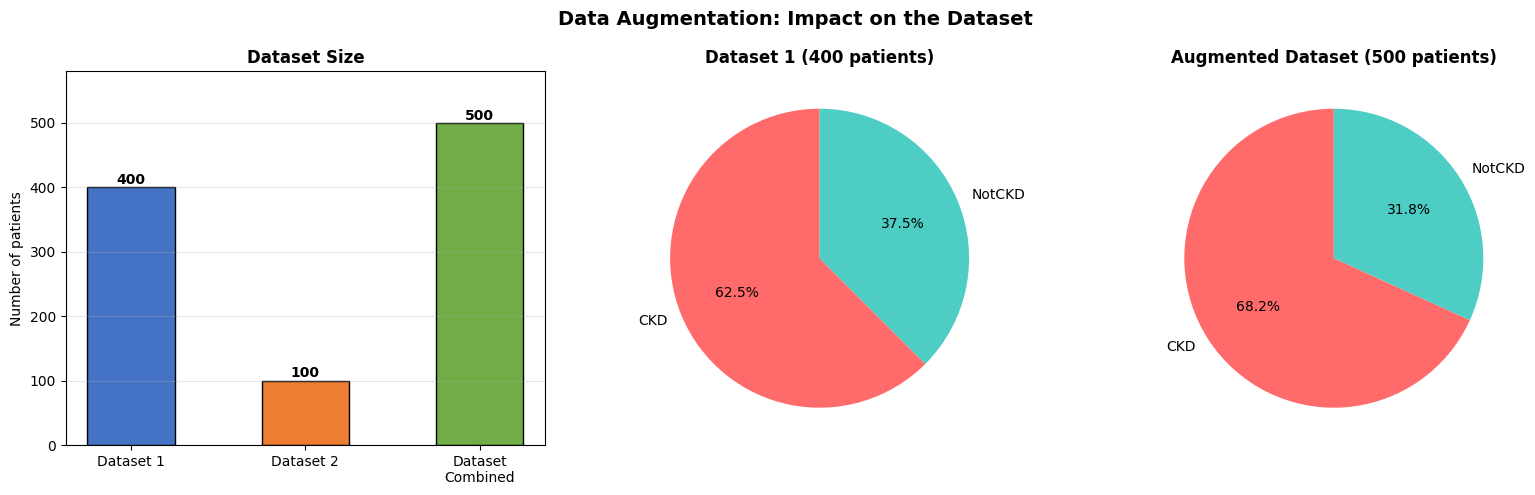

In [69]:
# VISUALIZATION: Before/After Augmentation Comparison

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Data Augmentation: Impact on the Dataset',
             fontsize=14, fontweight='bold')

# Graph 1: Dataset size
sizes = [400, 100, 500]
labels = ['Dataset 1\n', 'Dataset 2\n', 'Dataset\nCombined']
colors = ['#4472C4', '#ED7D31', '#70AD47']
bars = axes[0].bar(labels, sizes, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Dataset Size', fontweight='bold')
axes[0].set_ylabel('Number of patients')
for bar, size in zip(bars, sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5, str(size),
                 ha='center', fontweight='bold')
axes[0].set_ylim(0, 580)
axes[0].grid(axis='y', alpha=0.3)

# Graph 2: Dataset 1 class distribution
d1_counts = df_clean['classification'].value_counts()
axes[1].pie([d1_counts.get(1,0), d1_counts.get(0,0)],
            labels=['CKD', 'NotCKD'],
            colors=['#FF6B6B', '#4ECDC4'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Dataset 1 (400 patients)', fontweight='bold')

# Graph 3: Augmented Dataset Class Distribution
aug_counts = df_augmented['classification'].value_counts()
axes[2].pie([aug_counts.get(1,0), aug_counts.get(0,0)],
            labels=['CKD', 'NotCKD'],
            colors=['#FF6B6B', '#4ECDC4'],
            autopct='%1.1f%%', startangle=90)
axes[2].set_title('Augmented Dataset (500 patients)', fontweight='bold')

plt.tight_layout()
plt.show()


In [70]:
# Augmented Dataset Usage

from sklearn.preprocessing import StandardScaler

# Separate features and target from the AUGMENTED dataset
X_aug = df_augmented.drop('classification', axis=1)
y_aug = df_augmented['classification'].astype(int)

# Augmented dataset normalization
scaler_aug = StandardScaler()
X_aug_scaled = scaler_aug.fit_transform(X_aug)

print("=" * 55)
print("Augmented dataset ready for the next steps:")
print("=" * 55)
print(f"   X_aug shape: {X_aug.shape}")
print(f"   y_aug shape: {y_aug.shape}")
print(f"   CKD:    {int(y_aug.sum())} patients")
print(f"   NotCKD: {int((y_aug==0).sum())} patients")


Augmented dataset ready for the next steps:
   X_aug shape: (500, 24)
   y_aug shape: (500,)
   CKD:    341 patients
   NotCKD: 159 patients


---
## STEP 4: Feature Engineering

In [71]:
# FEATURE ENGINEERING
X = df_augmented.drop('classification', axis=1)
y = df_augmented['classification'].astype(int)

print(f"Features(X): {X.shape}")
print(f"Target(y): {y.shape}")
print(f"Columns: {list(X.columns)}")

Features(X): (500, 24)
Target(y): (500,)
Columns: ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


In [72]:
# STANDARDIZATION: StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Normalization: StandardScaler")
print(f"Average after normalization: {X_scaled.mean().round(4)} (≈ 0)")
print(f" Standard deviation after normalization: {X_scaled.std().round(4)} (≈ 1)")

Normalization: StandardScaler
Average after normalization: -0.0 (≈ 0)
 Standard deviation after normalization: 1.0 (≈ 1)


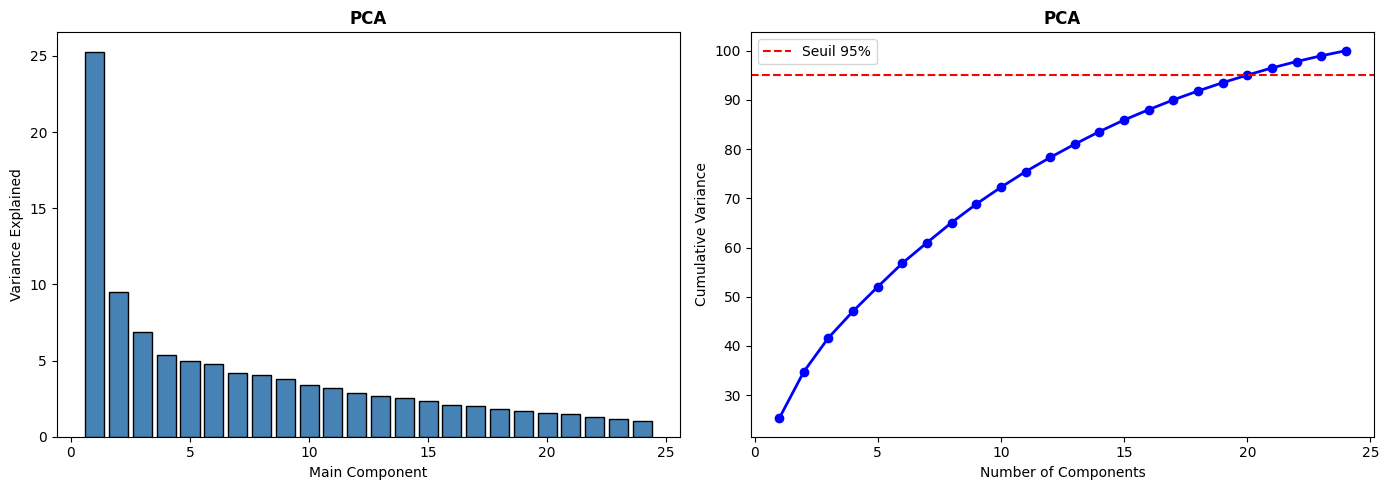


 Components needed for 95% of the variance: 20


In [73]:
#PCA: Principal Component Analysis

pca_full = PCA()
pca_full.fit(X_scaled)

# Cumulative variance explained
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_*100, color='steelblue', edgecolor='black')
axes[0].set_title('PCA', fontweight='bold')
axes[0].set_xlabel('Main Component')
axes[0].set_ylabel('Variance Explained')

# Cumulative variance
axes[1].plot(range(1, len(cumvar)+1), cumvar, 'bo-', linewidth=2)
axes[1].axhline(y=95, color='red', linestyle='--', label='Seuil 95%')
axes[1].set_title('PCA', fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].legend()

plt.tight_layout()
plt.show()
# Find the number of components for 95% of the variance
n_components_95 = np.argmax(cumvar >= 95) + 1
print(f"\n Components needed for 95% of the variance: {n_components_95}")

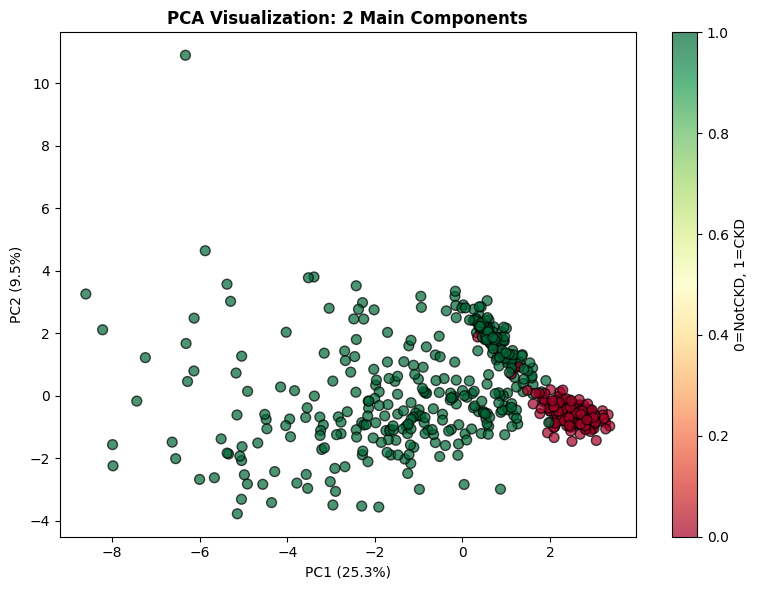

Variance explained by PC1: 25.29%
Variance explained by PC2: 9.48%

Final PCA: 24 features → 20 components


In [77]:
# PCA application with 2 components for 2D visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                      c=y, cmap='RdYlGn', alpha=0.7, edgecolors='k', s=50)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA Visualization: 2 Main Components', fontweight='bold')
plt.colorbar(scatter, label='0=NotCKD, 1=CKD')
plt.tight_layout()
plt.show()

print(f"Variance explained by PC1: {pca_2d.explained_variance_ratio_[0]*100:.2f}%")
print(f"Variance explained by PC2: {pca_2d.explained_variance_ratio_[1]*100:.2f}%")

# Final PCA with n_components for 95%
pca_final = PCA(n_components=n_components_95)
X_pca = pca_final.fit_transform(X_scaled)
print(f"\nFinal PCA: {X.shape[1]} features → {n_components_95} components")

LDA applied: 24 features → 1 component
Variance explained by LDA: 100.00%


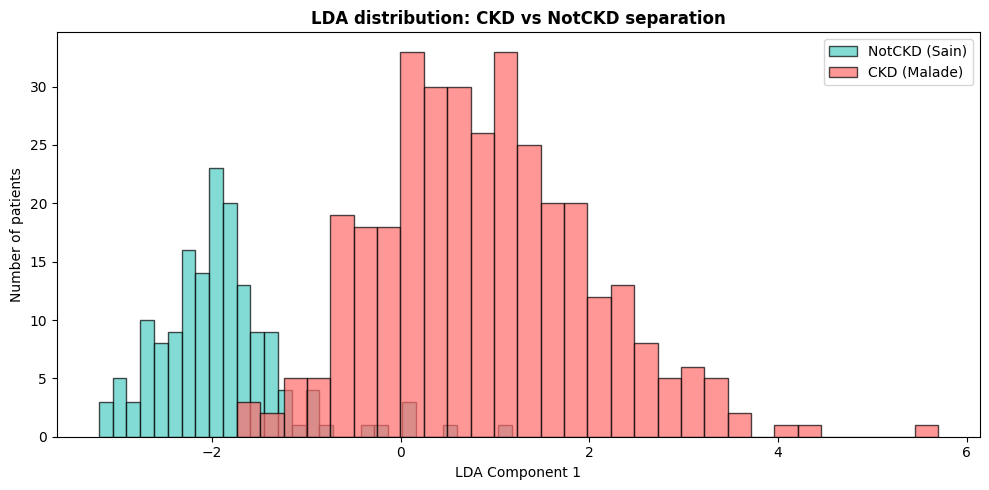

In [78]:
# LDA — Linear Discriminant Analysis

lda = LinearDiscriminantAnalysis()
X_lda = lda.fit_transform(X_scaled, y)

print(f"LDA applied: {X.shape[1]} features → {X_lda.shape[1]} component")
print(f"Variance explained by LDA: {lda.explained_variance_ratio_[0]*100:.2f}%")

# LDA Visualization
plt.figure(figsize=(10, 5))
for label, color, name in [(0, '#4ECDC4', 'NotCKD (Sain)'), (1, '#FF6B6B', 'CKD (Malade)')]:
    plt.hist(X_lda[y == label, 0], bins=30, alpha=0.7, color=color, label=name, edgecolor='black')
plt.xlabel('LDA Component 1')
plt.ylabel('Number of patients')
plt.title('LDA distribution: CKD vs NotCKD separation', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

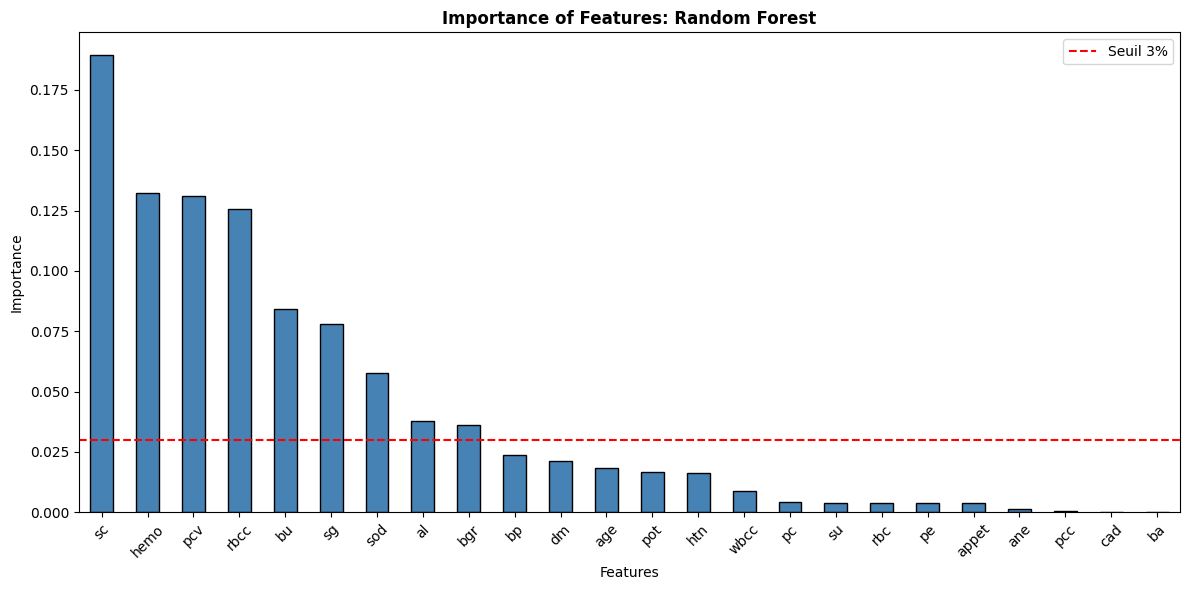


 Top 10 most important features:
    1. sc: 18.94%
    2. hemo: 13.24%
    3. pcv: 13.09%
    4. rbcc: 12.57%
    5. bu: 8.43%
    6. sg: 7.81%
    7. sod: 5.78%
    8. al: 3.79%
    9. bgr: 3.60%
   10. bp: 2.39%

 Selected features: 10 features


In [79]:
# SELECTION OF IMPORTANT FEATURES

rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_scaled, y)


feature_importance = pd.Series(
    rf_selector.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Visualization
plt.figure(figsize=(12, 6))
feature_importance.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Importance of Features: Random Forest', fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.axhline(y=0.03, color='red', linestyle='--', label='Seuil 3%')
plt.legend()
plt.tight_layout()
plt.show()

# Top 10 features
top_features = feature_importance.head(10).index.tolist()
print(f"\n Top 10 most important features:")
for i, (feat, imp) in enumerate(feature_importance.head(10).items(), 1):
    print(f"   {i:2d}. {feat}: {imp*100:.2f}%")

# Final dataset with the best features
X_selected = X[top_features]
X_selected_scaled = scaler.fit_transform(X_selected)
print(f"\n Selected features: {X_selected.shape[1]} features")

---
## STEP 5: Data Splitting

In [80]:
# TECHNIQUE 1: Train / Validation / Split Test

# Using the selected features
X_final = X_selected_scaled
y_final = y.values

# First split: 80% train+val / 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_final, y_final,
    test_size=0.20,
    random_state=42,
    stratify=y_final
)

# Second split: 75% train / 25% valley (out of 80% of the total → 60%/20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.25,
    random_state=42,
    stratify=y_trainval
)

print("=" * 50)
print("SPLIT 1 : Formation / Validation / Test")
print("=" * 50)
print(f"Train:      {X_train.shape[0]} patients ({X_train.shape[0]/len(X_final)*100:.0f}%)")
print(f"Validation: {X_val.shape[0]} patients ({X_val.shape[0]/len(X_final)*100:.0f}%)")
print(f"Test:       {X_test.shape[0]} patients ({X_test.shape[0]/len(X_final)*100:.0f}%)")

SPLIT 1 : Formation / Validation / Test
Train:      300 patients (60%)
Validation: 100 patients (20%)
Test:       100 patients (20%)


In [83]:
# TECHNIQUE 2 : Validation croisée à K plis

K = 5 # Nombre de folds
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

print(f"SPLIT 2: {K}-Fold Stratified Cross Validation")
print("=" * 50)

# Demonstration of the distribution for each fold
for fold, (train_idx, val_idx) in enumerate(skf.split(X_final, y_final), 1):
    print(f"   Fold {fold}: Train={len(train_idx)} | Val={len(val_idx)} "
          f"(CKD train: {y_final[train_idx].sum()}, CKD val: {y_final[val_idx].sum()})")

print(f"The K-Fold will be used for model evaluation")

SPLIT 2: 5-Fold Stratified Cross Validation
   Fold 1: Train=400 | Val=100 (CKD train: 273, CKD val: 68)
   Fold 2: Train=400 | Val=100 (CKD train: 273, CKD val: 68)
   Fold 3: Train=400 | Val=100 (CKD train: 273, CKD val: 68)
   Fold 4: Train=400 | Val=100 (CKD train: 273, CKD val: 68)
   Fold 5: Train=400 | Val=100 (CKD train: 272, CKD val: 69)
The K-Fold will be used for model evaluation


---
## STEP 6: Algorithm Selection

In [84]:
# DEFINITION OF MODELS
models = {
    # ML Algorithms
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine (SVM)': SVC(probability=True, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    # DL-like / Ensemble
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

print("Defined models:")
for name in models:
    print(f"   {name}")

Defined models:
   Logistic Regression
   Decision Tree
   K-Nearest Neighbors
   Support Vector Machine (SVM)
   Random Forest
   Gradient Boosting


---
## STEP 7: Training


In [86]:
# TRAINING FOR ALL MODELS

results = {}
print(f"{'Model':<40} {'Val Acc':>8} {'CV Mean':>8} {'CV Std':>7}")
print("=" * 65)

for name, model in models.items():
   #  Training
    model.fit(X_train, y_train)
  # Validation Prediction
    y_pred_val = model.predict(X_val)
    val_acc = accuracy_score(y_val, y_pred_val)

    # Cross-Validation (K-Fold)
    cv_scores = cross_val_score(
        model, X_final, y_final,
        cv=skf,
        scoring='accuracy'
    )

    # Storing results
    results[name] = {
        'model': model,
        'val_accuracy': val_acc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'cv_scores': cv_scores
    }

    print(f"{name:<40} {val_acc:>8.4f} {cv_scores.mean():>8.4f} {cv_scores.std():>7.4f}")

print("=" * 65)
print("Training complete for all models")

Model                                     Val Acc  CV Mean  CV Std
Logistic Regression                        0.9800   0.9640  0.0196
Decision Tree                              0.9700   0.9320  0.0075
K-Nearest Neighbors                        0.9500   0.9640  0.0162
Support Vector Machine (SVM)               0.9900   0.9680  0.0133
Random Forest                              0.9800   0.9740  0.0136
Gradient Boosting                          0.9800   0.9760  0.0102
Training complete for all models


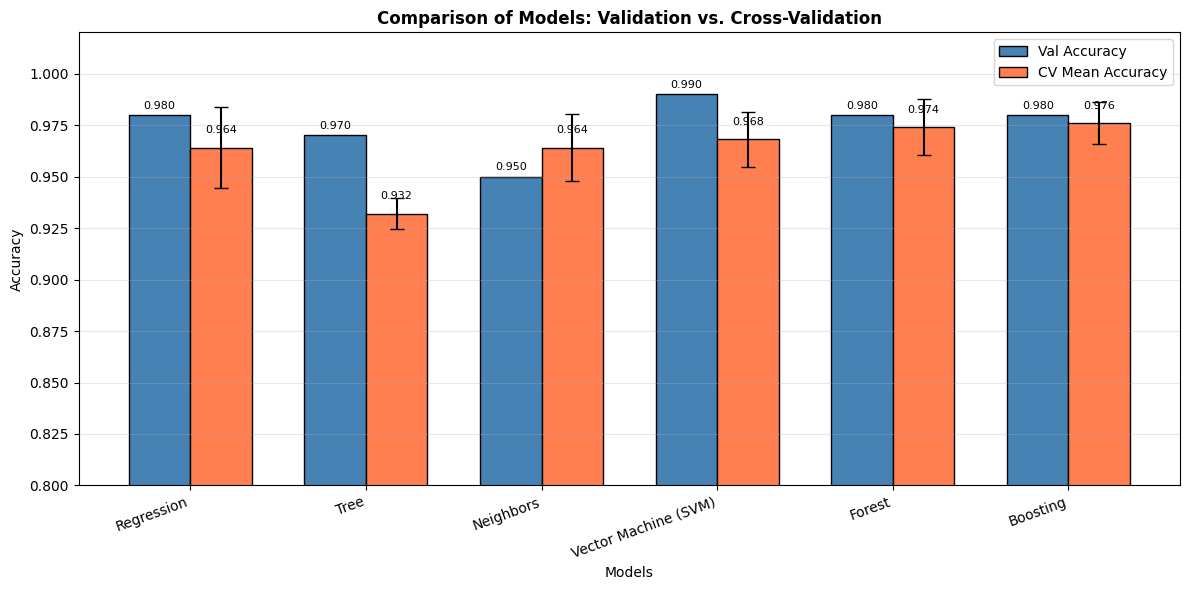

In [87]:
# VISUALIZATION: Comparison of models

# Preparing data for visualization
model_names = [name.split(' ', 1)[1] for name in results.keys()]  # Retirer émoji
cv_means = [r['cv_mean'] for r in results.values()]
cv_stds = [r['cv_std'] for r in results.values()]
val_accs = [r['val_accuracy'] for r in results.values()]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(model_names))
width = 0.35

bars1 = ax.bar(x - width/2, val_accs, width, label='Val Accuracy', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, cv_means, width, label='CV Mean Accuracy',
               color='coral', edgecolor='black', yerr=cv_stds, capsize=5)

ax.set_xlabel('Models')
ax.set_ylabel('Accuracy')
ax.set_title('Comparison of Models: Validation vs. Cross-Validation', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylim(0.8, 1.02)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add the values ​​to the bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.006,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

---
## STEP 8 : Evaluation


In [88]:
# SELECTION OF THE BEST MODEL

# The best model = the one with the best CV mean accuracy
best_name = max(results, key=lambda k: results[k]['cv_mean'])
best_model = results[best_name]['model']

print(f"Best model: {best_name}")
print(f"   CV Mean Accuracy: {results[best_name]['cv_mean']:.4f}")
print(f"   CV Std:           {results[best_name]['cv_std']:.4f}")

Best model: Gradient Boosting
   CV Mean Accuracy: 0.9760
   CV Std:           0.0102


In [89]:
# COMPLETE EVALUATION OF THE BEST MODEL

# Predictions on the TEST set
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]  # Probabilités pour ROC

#  ACCURACY
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"\n  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# CLASSIFICATION REPORT
print("\nCLASSIFICATION REPORT:")
print("=" * 55)
print(classification_report(y_test, y_pred_test,
                             target_names=['NotCKD (Sain)', 'CKD (Malade)']))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob_test)
print(f"\n ROC-AUC Score: {roc_auc:.4f}")


  0.9800 (98.00%)

CLASSIFICATION REPORT:
               precision    recall  f1-score   support

NotCKD (Sain)       0.97      0.97      0.97        32
 CKD (Malade)       0.99      0.99      0.99        68

     accuracy                           0.98       100
    macro avg       0.98      0.98      0.98       100
 weighted avg       0.98      0.98      0.98       100


 ROC-AUC Score: 0.9982


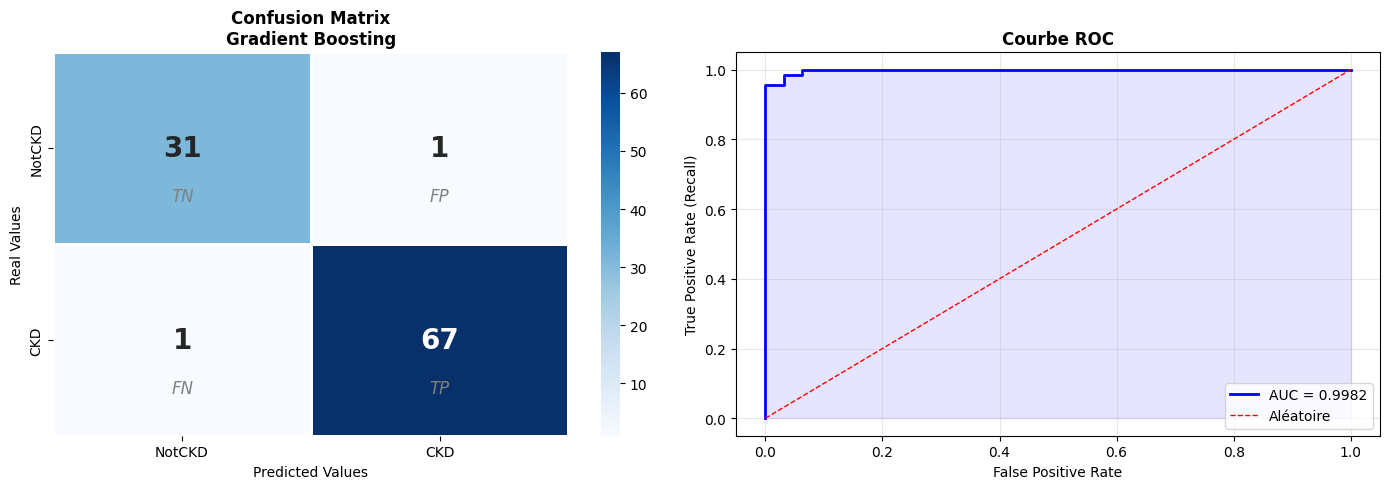

In [90]:
# CONFUSION MATRIX
# The confusion matrix shows:
# - TP (True Positive): Sick individuals correctly detected
# - TN (True Negative): Healthy individuals correctly identified
# - FP (False Positive): Healthy individuals classified as sick (False alarm)
# - FN (False Negative): Sick individuals not detected (DANGEROUS in medicine!)

cm = confusion_matrix(y_test, y_pred_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NotCKD', 'CKD'],
            yticklabels=['NotCKD', 'CKD'],
            ax=axes[0], linewidths=2, linecolor='white',
            annot_kws={'size': 20, 'weight': 'bold'})
axes[0].set_title(f'Confusion Matrix\n{best_name}', fontweight='bold')
axes[0].set_ylabel('Real Values')
axes[0].set_xlabel('Predicted Values')

# Added TP/TN/FP/FN labels
labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        axes[0].text(j + 0.5, i + 0.75, labels[i][j],
                     ha='center', va='center', fontsize=12,
                     color='gray', style='italic')

# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Aléatoire')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='blue')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('Courbe ROC', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [91]:
# EVALUATION OF ALL MODELS (Comparative)
print("\n COMPARATIVE TABLE OF ALL MODELS:")
print("=" * 75)
print(f"{'Model':<42} {'Accuracy':>9} {'AUC':>8} {'F1-CKD':>8}")
print("=" * 75)

all_results = []
for name, res in results.items():
    model = res['model']
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)
    f1_ckd = report['1']['f1-score']  # F1 pour la classe CKD

    all_results.append({'Model': name, 'Accuracy': acc, 'AUC': auc, 'F1-CKD': f1_ckd})
    marker = " ← MEILLEUR" if name == best_name else ""
    print(f"{name:<42} {acc:>9.4f} {auc:>8.4f} {f1_ckd:>8.4f}{marker}")

print("=" * 75)


 COMPARATIVE TABLE OF ALL MODELS:
Model                                       Accuracy      AUC   F1-CKD
Logistic Regression                           0.9700   0.9922   0.9781
Decision Tree                                 0.9500   0.9550   0.9624
K-Nearest Neighbors                           0.9600   0.9809   0.9706
Support Vector Machine (SVM)                  0.9700   0.9917   0.9781
Random Forest                                 0.9800   0.9949   0.9853
Gradient Boosting                             0.9800   0.9982   0.9853 ← MEILLEUR


---
## STEP 9: Result Analysis

DETAILED ANALYSIS OF THE RESULTS

 Statistical summary of metrics:
       Accuracy     AUC  F1-CKD
count    6.0000  6.0000  6.0000
mean     0.9683  0.9855  0.9766
std      0.0117  0.0160  0.0089
min      0.9500  0.9550  0.9624
25%      0.9625  0.9836  0.9725
50%      0.9700  0.9920  0.9781
75%      0.9775  0.9943  0.9835
max      0.9800  0.9982  0.9853

 Best model by Accuracy: Random Forest
Best model by AUC:     Gradient Boosting
Best model by F1-CKD:   Random Forest


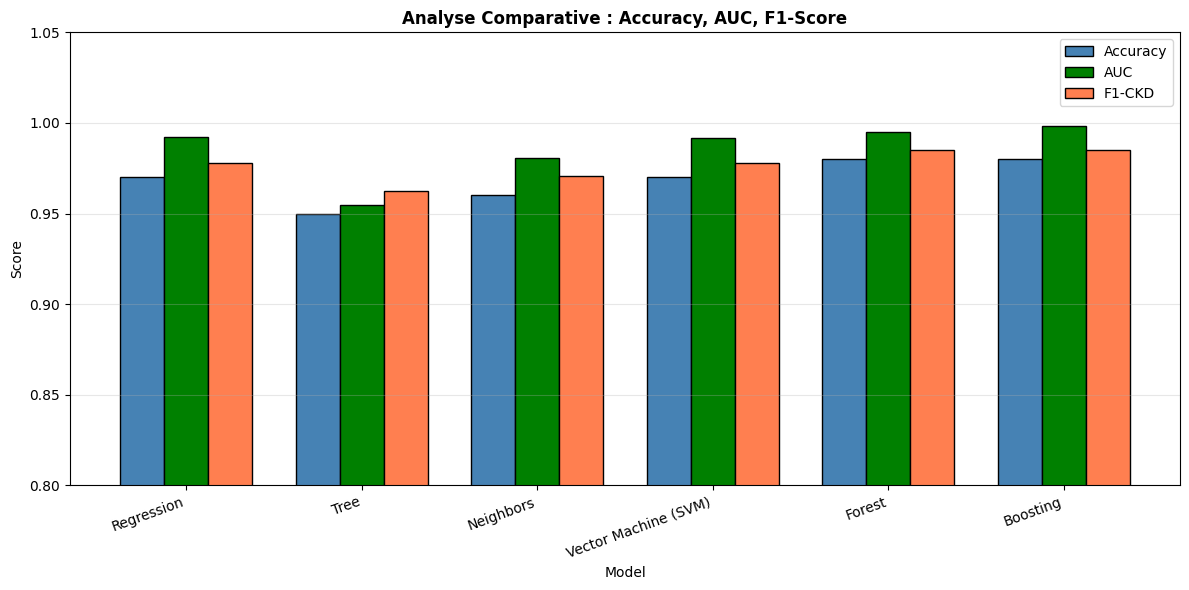

In [92]:
# ANALYSIS OF RESULTS
results_df = pd.DataFrame(all_results)

print("=" * 60)
print("DETAILED ANALYSIS OF THE RESULTS")
print("=" * 60)

print("\n Statistical summary of metrics:")
print(results_df[['Accuracy', 'AUC', 'F1-CKD']].describe().round(4))

print(f"\n Best model by Accuracy: {results_df.loc[results_df['Accuracy'].idxmax(), 'Model']}")
print(f"Best model by AUC:     {results_df.loc[results_df['AUC'].idxmax(), 'Model']}")
print(f"Best model by F1-CKD:   {results_df.loc[results_df['F1-CKD'].idxmax(), 'Model']}")

# Visualisation comparative
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results_df))
width = 0.25
short_names = [n.split(' ', 1)[1][:20] for n in results_df['Model']]

ax.bar(x - width, results_df['Accuracy'], width, label='Accuracy', color='steelblue', edgecolor='black')
ax.bar(x,          results_df['AUC'],      width, label='AUC',      color='green',     edgecolor='black')
ax.bar(x + width,  results_df['F1-CKD'],   width, label='F1-CKD',   color='coral',     edgecolor='black')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Analyse Comparative : Accuracy, AUC, F1-Score', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=20, ha='right')
ax.set_ylim(0.8, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## STEP 10: Model Enhancement

In [93]:
# HYPERPARAMETER: GridSearchCV

from sklearn.model_selection import GridSearchCV

print("Hyperparameter Tuning en cours...")


param_grid_rf = {
    'n_estimators':      [50, 100, 200],   # Number of trees
    'max_depth':         [None, 5, 10],    # Maximum depth of each tree
    'min_samples_split': [2, 5],           # Minimum samples to split a node
    'min_samples_leaf':  [1, 2],           # Minimum samples in a sheet
}

#GridSearchCV avec Cross-Validation
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=skf,                   # Use our StratifiedKFold
    scoring='roc_auc',        # Optimize for AUC
    n_jobs=-1,                # Use all available CPUs
    verbose=0
)

# Training
grid_search.fit(X_train, y_train)

print("Hyperparameter Tuning complete!")
print(f"\n Best hyperparameters:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n Best CV score (AUC): {grid_search.best_score_:.4f}")

Hyperparameter Tuning en cours...
Hyperparameter Tuning complete!

 Best hyperparameters:
   max_depth: None
   min_samples_leaf: 2
   min_samples_split: 5
   n_estimators: 200

 Best CV score (AUC): 0.9738


In [98]:
# BEFORE/AFTER TUNING COMPARISON

# Basic model (Random Forest by default)
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)
y_prob_base = rf_base.predict_proba(X_test)[:, 1]

# Optimized model
best_model_tuned = grid_search.best_estimator_
y_pred_tuned = best_model_tuned.predict(X_test)
y_prob_tuned = best_model_tuned.predict_proba(X_test)[:, 1]

# Comparison
print("=" * 55)
print("COMPARAISON AVANT/APRÈS HYPERPARAMETER TUNING")
print("=" * 55)
metrics = [
    ('Accuracy', accuracy_score(y_test, y_pred_base), accuracy_score(y_test, y_pred_tuned)),
    ('AUC',      roc_auc_score(y_test, y_prob_base),  roc_auc_score(y_test, y_prob_tuned)),
]

print(f"{'Metric':<15} {'Avant Tuning':>14} {'After Tuning':>14} {'Improvement':>14}")
print("-" * 55)
for metric, before, after in metrics:
    diff = after - before
    arrow = '📈' if diff > 0 else '📉' if diff < 0 else '➡️'
    print(f"{metric:<15} {before:>14.4f} {after:>14.4f} {arrow} {diff:+.4f}")

print("\nThe tuned model will be saved as the final model")

COMPARAISON AVANT/APRÈS HYPERPARAMETER TUNING
Metric            Avant Tuning   After Tuning    Improvement
-------------------------------------------------------
Accuracy                0.9800         0.9800 ➡️ +0.0000
AUC                     0.9949         0.9913 📉 -0.0037

The tuned model will be saved as the final model
